# Airbnb en Nueva York
Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

#### Paso 1: Carga del conjunto de datos
    Puedes descargar el conjunto de datos directamente desde Kaggle.com o en el siguiente enlace: https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv. Almacena los datos en crudo en la carpeta ./data/raw.

#### Paso 2: Realiza un EDA completo
    Este paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

        Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en la lección.

#### Paso 3: Guarda el conjunto de datos procesado
    Después del EDA puedes guardar los datos en la carpeta ./data/processed. Asegúrate de agregar la carpeta de los datos en el .gitignore. Los datos al igual que los modelos no se deben subir a git.

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import json
import os
#como vimos en clase teniamos un train y un test, pero en este caso como solo tenemos un csv nos apoyamos de una libreria llamada "sklearn" para dividir el dataframe
from sklearn.model_selection import train_test_split

In [175]:
# Cargamos el dataset
total_data = pd.read_csv('../data/raw/AB_NYC_2019.csv')
#imprimimos los primeros 5
total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [176]:
#imprimimos el numero de filas
print(f"Numero De Filas en 'total_data': {len(total_data)}")
# Verificamos La Cantidad De Variables Por Tipos De Datos, en el ejericio que vimos "str" era tratado como "object" por la funcion "pd.value_counts(total_data.dtypes)" 
# pero como la funcion que usamos en su momento estaba deprecada, use esta:
pd.Series.value_counts(total_data.dtypes)

Numero De Filas en 'total_data': 48895


int64      7
str        6
float64    3
Name: count, dtype: int64

In [177]:
#Obtenemos Información Sobre Los Tipos De Datos Y Valores No Nulos
info = total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [178]:
#Con este codigo estraido del colab visto en clases obtenemos que columnas tienen valores nulos y el que porcentage respectivamente
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending = False)

last_review                       20.558339
reviews_per_month                 20.558339
host_name                          0.042949
name                               0.032723
neighbourhood_group                0.000000
neighbourhood                      0.000000
id                                 0.000000
host_id                            0.000000
longitude                          0.000000
latitude                           0.000000
room_type                          0.000000
price                              0.000000
number_of_reviews                  0.000000
minimum_nights                     0.000000
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

<Axes: >

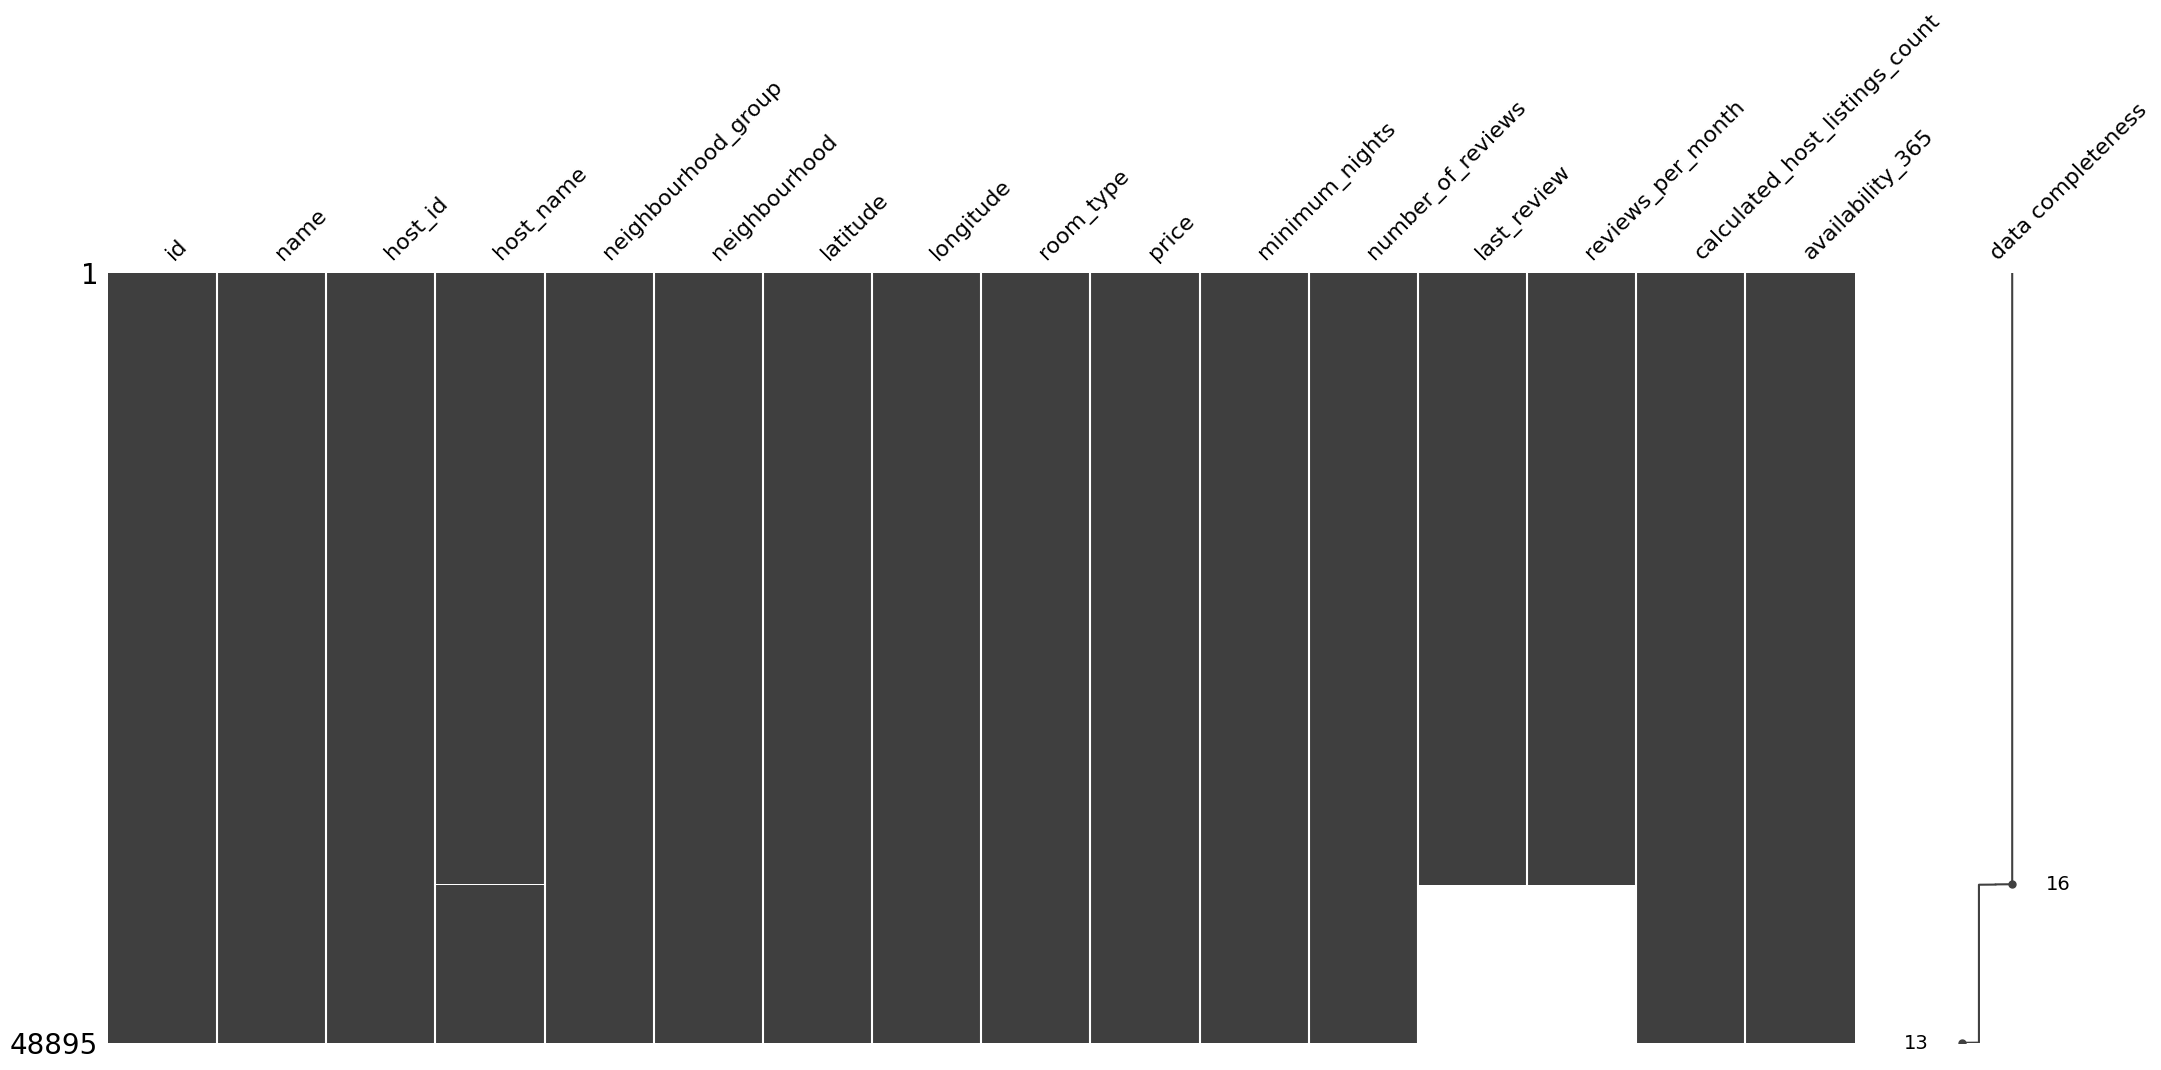

In [179]:
#Podemos Visualizar Los Datos Nulos como en clase
msno.matrix(total_data, labels = True, sort = "descending")

# Conclusiones (Hasta Ahora):
* Tenemos un dataframe con 16 columnas y 48895 filas, de las cuales 7 filas son int64, 6 str y 3 float64, 4 de esas columnas tienen valores nulos: 
    | Columna | Porcentaje de Nulos (%) |
    | :--- | :--- |
    | `last_review` | 20.56% |
    | `reviews_per_month` | 20.56% |
    | `host_name` | 0.04% |
    | `name` | 0.03% |
* Casi Todas las columnas estan con valores completos a excepcion `last_review` y `reviews_per_month`(`host_name` y `name` tambien pero en muy poca proporcion) 
* `last_review` y `reviews_per_month` tienen una coincidencia exacta si un dato es nulo el otro tambien.

In [180]:
#Ahora eliminar duplicados en columnas que deberian de ser estrictamente unicas.
# aunque hay varias columnas con algun tipo de identificador el unico que podemos estar seguro que es unico al 100% es el id principal por estructura de base de datos, el resto de ids como host_id hay que tratarlos con mas cuidado:
total_data.drop(columns = ['id']).duplicated().sum()
total_data[total_data[['id']].duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


In [181]:
#Revisemos Los Posibles Datos Categóricos
total_data.select_dtypes(include = ['str']).columns

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='str')

### Son Categorizables?:
* `name`: Nombre o título del anuncio muy pocos valores nulos a simple vista no categorizable
* `host_name`:Nombre del anfitrion, igual que el anterior no categorizable
* `neighbourhood_group`:El distrito principal Podemos agrupar.
* `neighbourhood`:El barrio específico dentro del distrito Tambien se puede intentar agrupar
* `room_type`:Tipo de alojamiento tambien se puede agrupar
* `last_review`:Fecha de la última reseña esta como str pero al fi y al cabo es numerica no categorizable al menos no sin transformar, procederemos a transformarlo a numerica. 
### Variables Categorizables: 
* `room_type`
* `neighbourhood_group`
* `neighbourhood`

In [182]:
#Usamos unique para obtener los valores sin que se repitan
room_type = total_data['room_type'].unique()
neighbourhood_group = total_data['neighbourhood_group'].unique()
neighbourhood = total_data['neighbourhood'].unique()
#impimimos los valores unicos para verlos mejor, buscando en internet vi que display imprime mejor que print ciertas cosas como los dataframe
#lo coloco asi porque sino solo va a imprimir el ultimo y quiero que imprima los tres
print("Valores unicos de room_type:")
display(pd.DataFrame(room_type, columns = ["Opciones"]))

print("Valores unicos de neighbourhood_group:")
display(pd.DataFrame(neighbourhood_group, columns = ["Opciones"]))

print("Valores unicos de neighbourhood:")
display(pd.DataFrame(neighbourhood, columns = ["Opciones"]))

Valores unicos de room_type:


,Opciones
0,Private room
1,Entire home/apt
2,Shared room


Valores unicos de neighbourhood_group:


,Opciones
0,Brooklyn
1,Manhattan
2,Queens
3,Staten Island
4,Bronx


Valores unicos de neighbourhood:


,Opciones
0,Kensington
1,Midtown
2,Harlem
3,Clinton Hill
4,East Harlem
...,...
216,Bull's Head
217,New Dorp
218,Rossville
219,Breezy Point


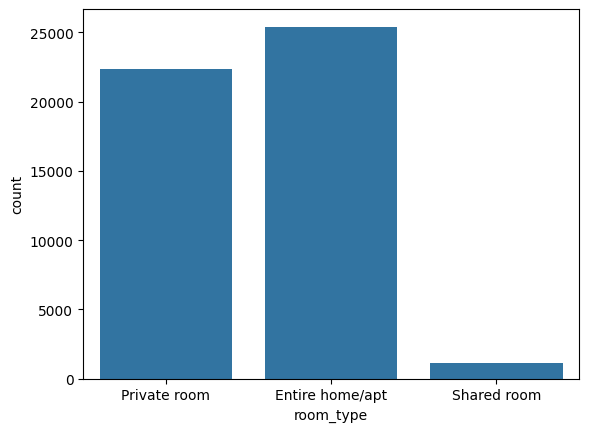

In [183]:
#Graficamos y obtenemos 3 posibles valores
sns.countplot(data = total_data, x = 'room_type')
#Luego Factorizamos y creamos una nueva columna
total_data["room_type_factor"] = pd.factorize(total_data["room_type"])[0]

In [184]:
#creamos una funcion para almacenar los cambios que hemos hecho en un json como vimos en clases
def create_changes_json(column, column_factor, df, allow_duplicates = False):
    #para eso usamos el ejemplo visto en el colab pero le quitamos los comentarios, lo dejamos en una linea, y añadimos una funcionalidad "allow_duplicates" para no solo guarde valores unicos
    #eso nos servira mas adelante para guardar las transformaciones
    file_name = ""
    
    # Creamos una copia para no alterar el data frame original
    df_aux = df[[column, column_factor]].copy()

    # Guardar timestamps con json es un poco complicado asi que hay que convertirlos antes de guardar el archivo
    for col in df_aux.columns:
        if pd.api.types.is_datetime64_any_dtype(df_aux[col]):
            df_aux[col] = df_aux[col].dt.strftime('%Y-%m-%d')
    
    if allow_duplicates:
        # Si permite duplicados, guardamos registro por registro (lista de diccionarios)
        file_name = f'{column}_transformation_rules.json'
        df_to_save = df_aux[[column, column_factor]]
        data_to_export = df_to_save.to_dict(orient = 'records')
    else:
        # Si NO permite (por defecto), creamos el diccionario de reglas único {Nombre: Factor}
        file_name = f'{column}_factory_rules.json'
        df_unique = df_aux[[column, column_factor]].drop_duplicates()
        data_to_export = {row[column]: row[column_factor] for _, row in df_unique.iterrows()}

    #Contruimos La Ruta
    folder_path = '../data/processed'
    full_path = os.path.join(folder_path, file_name)
    with open(full_path, 'w') as f:
        json.dump(data_to_export, f, indent=4)
    
    print(f"Json guardado en: {full_path}")
    
#luego usamos la funcion con la columna room_type
create_changes_json("room_type", "room_type_factor", total_data)

Json guardado en: ../data/processed\room_type_factory_rules.json


Json guardado en: ../data/processed\neighbourhood_group_factory_rules.json


<Axes: xlabel='neighbourhood_group', ylabel='count'>

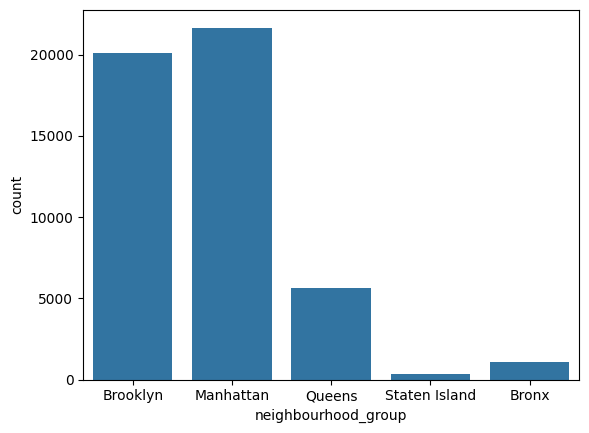

In [185]:
#Hacemos lo mismo que antes, factorizamos neighbourhood_group y usamos la funcion para guardar el json
total_data["neighbourhood_group_factor"] = pd.factorize(total_data["neighbourhood_group"])[0]
create_changes_json("neighbourhood_group", "neighbourhood_group_factor", total_data)
#Graficamos y obtenemos 5 posibles valores de neighbourhood_group
sns.countplot(data = total_data, x = 'neighbourhood_group')

<Axes: xlabel='neighbourhood', ylabel='count'>

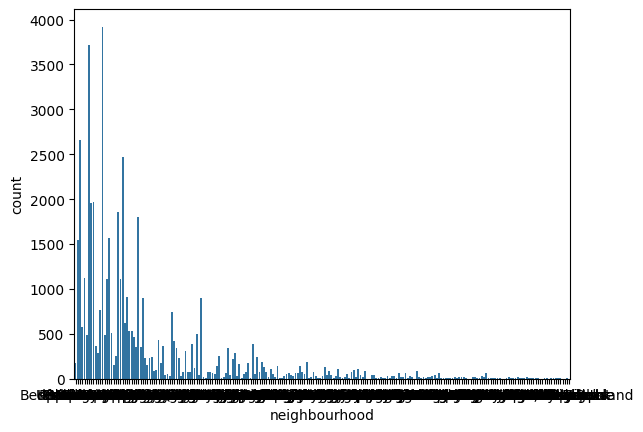

In [186]:
# Graficamos, pero hay mas barrios de los se tenia pensado, no la usaremos ni factorizamos esta variable pero la dejaremos 
# ya que el ejercicio no nos especifica buscar algo en concreto 
sns.countplot(data = total_data, x = 'neighbourhood')

In [ ]:
# Ahora seleccionamos variables numericas
total_data.select_dtypes(include = ['int', 'float']).columns

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'room_type_factor', 'neighbourhood_group_factor'],
      dtype='str')

### Variables Relevantes:

* **`latitude` / `longitude`**  Coordenadas geograficas,  Permiten un analisis del precio a nivel geografico, como ya conocemos el `neighbourhood` podriamos obviar esta variable **Podria ser relevante**. 
* **`price`**  Precio por noche,Posible Variable a predecir. **es relevante**. 
* **`minimum_nights`**  Noches minimas de reserva,  Puede definir la causa de tomar el hospedaje como trabajo,vacaciones,etc **es relevante**. 
* **`reviews_per_month`**  Reseñas mensuales,  Indica demanda actual puede tener relacion con el precio **es relevante**. 
* **`number_of_reviews`**  Total de reseñas,  Puede tener relacion con el precio pero el anterior indicador puede darnos mas informacion **Podria ser relevante**. 
* **`calculated_host_listings_count`**  Numero de anuncios de algun dueño util para identificar a personas que alquilan su cada o empresas que tienen multi-propiedades  **es relevante**. 
* **`availability_365`**  Disponibilidad anual,  Al igual que minimum_nights puede indicarnos la causa de tomar el hospedaje **Podria ser relevante**. 
* **`last_review`** Como digimos oiriginalmente es srt por la estructura de una fecha YYYY-MM-DD pero vamos a tranformarla a numerica



In [188]:
#Ahora Vamos a crear la columna last_review_transf a partir de last_rewiew
total_data['last_review'] = pd.to_datetime(total_data['last_review'])
#vi en internet que los modelos trabajan mejor las fechas con el formato unix entonses aplicamos este codigo que vi en: "https://stackoverflow.com/questions/15203623/convert-pandas-datetimeindex-to-unix-time"
total_data['last_review_transf'] = total_data['last_review'].values.astype('int64') // 10**9
#luego como los valores nulos los va a convertir a numeros negativos los volvemos a pasar a nulos
total_data.loc[total_data['last_review_transf'] < 0, 'last_review_transf'] = np.nan
total_data.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,room_type_factor,neighbourhood_group_factor,last_review_transf
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,0,0,1539907.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,1,1,1558396.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,0,1,NaN
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1,0,1562284.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,1,1,1542585.0


#### El Siguiente Paso es rellenar los valores nulos 
    De las variables que nos quedan last_rewiew_transf y reviewa_per_mouth eran las que quedaban con valores nulos

In [189]:
total_data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,room_type_factor,neighbourhood_group_factor,last_review_transf
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000,48895.000000,48895.000000,3.884300e+04
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099,1.373221,7.143982,112.781327,0.567113,0.786911,1.538617e+06
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000,0.000000,0.000000,1.301270e+06
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000,0.000000,0.000000,1.531008e+06
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000,1.000000,1.000000,1.558224e+06
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000,1.000000,1.000000,1.561248e+06
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000,2.000000,4.000000,1.562544e+06
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289,0.541249,0.844386,3.576243e+04


In [ ]:
#En clase para rellenar nulos vimos: 
    #CUANDO UNA VARIABLE ES ENTERA PERO NUMÉRICA == INCONTABLE == 0 A LOS 130 == TIENE MUCHOS VALORES
    #total_data['Age'] = total_data['Age'].fillna(total_data['Age'].median())
    
#Entonses para last_review_transf que es un entero unix usamos la mediana
total_data['last_review_transf'] = total_data['last_review_transf'].fillna(total_data['last_review_transf'].median())

#segun lo que vimos en clases usamos la media cuando es puramente decimal como en el caso de "reviews_per_month" pero aca tenemos que el valor maximo es "58.5" se aleja mucho de del 75% por lo que la mediana seguira siendo mejor
#opcion puesto que se ve menos afectada por estos valores atipicos.
total_data['reviews_per_month'] = total_data['reviews_per_month'].fillna(total_data['reviews_per_month'].median())

print(total_data.isnull().sum())
#ahora que reviews_per_month no tiene valores nulos reusamos la funcion de antes para guardar los cambios de la transformacion
create_changes_json("last_review", "last_review_transf", total_data, True)

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
room_type_factor                      0
neighbourhood_group_factor            0
last_review_transf                    0
dtype: int64
Json guardado en: ../data/processed\last_review_transformation_rules.json


### **Variables Irrelevantes**
En este caso vamos a analizar nuestras columnas:
* **`id`**: Es un número aleatorio para la base de datos no es relevante para predicciones.
* **`name`**: Es texto libre. para un modelo estándar es ruido, quisas para otros analisis si fuera relevante.
* **`host_id`**: No aporta valor predictivo directo a no ser que los ids se construyan de una manera no aleatorea, pero de ser asi lo desconocemos.
* **`host_name`**: Igual que el nombre del anuncio, es irrelevante.
* **`neighbourhood_group`**:Como ya lo factorizamos y almacenamos el json de referencia podemos eliminarlo
* **`room_type`**:Como ya lo factorizamos y almacenamos el json de referencia podemos eliminarlo
* **`last_review`**:Como ya los transformamos y almacenamos el json de referencia podemos eliminarlo

In [ ]:
#eliminamos las columnas
total_data.drop(["id", "name", "host_id", "host_name", "neighbourhood_group", "room_type", "last_review"],  axis = 1,  inplace = True)
total_data.head()

,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_factor,neighbourhood_group_factor,last_review_transf
0,Kensington,40.64749,-73.97237,149,1,9,0.21,6,365,0,0,1539907.0
1,Midtown,40.75362,-73.98377,225,1,45,0.38,2,355,1,1,1558396.0
2,Harlem,40.80902,-73.94190,150,3,0,0.72,1,365,0,1,1558224.0
3,Clinton Hill,40.68514,-73.95976,89,1,270,4.64,1,194,1,0,1562284.0
4,East Harlem,40.79851,-73.94399,80,10,9,0.10,1,0,1,1,1542585.0


### Cuales tomamos?:
    Como digimos al no buscar algo en concreto no es recomendable eliminar datos que podrian ser relevantes a no ser que lo hallamos factorizado o transformado por lo que al final nos quedan estas:

##### Categoricas(Factorizadas):
* **`neighbourhood_group_factor`**
* **`room_type_factor`**

##### Categoricas(Tranformadas):
* **`last_review_trasf`**

##### Numericas:
* **`latitude`**
* **`longitude`**
* **`price`**
* **`minimum_nights`**
* **`reviews_per_month`**
* **`number_of_reviews`**
* **`calculated_host_listings_count`**
* **`availability_365`**



In [192]:
# Vamos a dividir 80% para entrenar y 20% para evaluar, usamos "train_test_split" como vimos en clases.
# "test_size" es el porcentaje que vamos a agarrar para lo test y "random_state" es como el seed de los random, es para que en cada ejecucion no se cambien los valores
train_data, test_data = train_test_split(total_data, test_size = 0.2, random_state = 42)

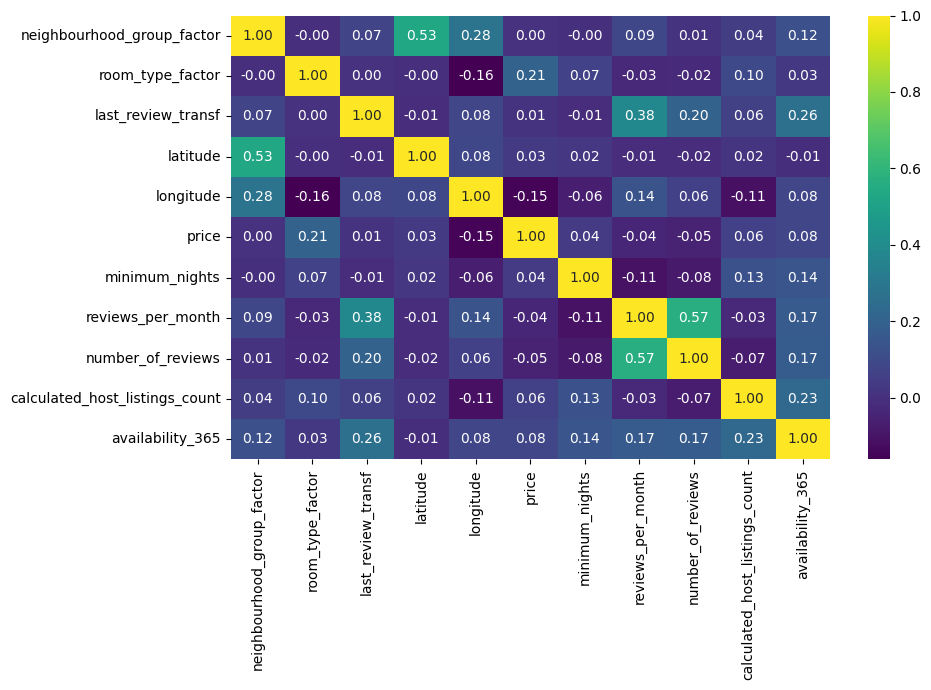

In [ ]:
#Graficamos en un heatmap para ver las correlaciones
cols_num=["neighbourhood_group_factor", "room_type_factor", "last_review_transf", "latitude", "longitude", "price", "minimum_nights", "reviews_per_month", "number_of_reviews", "calculated_host_listings_count", "availability_365"]
fig, ax = plt.subplots(figsize=(10,  7))
sns.heatmap(total_data[cols_num].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "viridis",ax = ax)
plt.tight_layout()
plt.show()

## Conclusiones
* `room_type_factor` y `price` tienen una correlacion de 0.21 es decir el tipo de hospedaje afecta al precio
* Hay ciertas correlaciones relacionadas con la `latitud` y la `longitud` pero como estamos haciendo analizis geograficos avanzados no los tomaremos en cuenta.
* `last_review_transf` tiene una correlacion de 0.38 con `reviews_per_month` y 0.26 con `availability_365`, indica que los alojamientos con reseñas recientes suelen ser los mas activos,y con mas disponibilidad.
*`reviews_per_month` y `number_of_reviews` pueden se redundantes al tener una correlacion tan alta 0.57 y una similaridad de variable en cuanto que es lo que representa, en este caso reviews.

In [194]:
total_data.to_csv('../data/processed/AB_NYC_2019_processed.csv', index = True)
print("Archivo Guardado ")

Archivo Guardado 
